# Permutation-equivariant quantum neural network (QNN) for graph classification with $\mathfrak{g}$-sim

This notebook demonstrates how to build and evaluate the permutation-equivariant QNN loss used in the graph-state classification example from the manuscript. In that setup, a graph $G=(V,E)$ on $n$ vertices is encoded as the graph state

$$
|G\rangle = \left(\prod_{(i,j)\in E} \mathrm{CZ}_{ij}\right)|+\rangle^{\otimes n},
$$

and the model is an $S_n$-equivariant ansatz generated by three permutation-invariant Hamiltonians. In Pauli-orbit notation, one layer is

$$
U_\ell(\alpha_\ell,\beta_\ell,\gamma_\ell)
=
\exp\!\bigl(-\alpha_\ell B_{1,0,0}\bigr)
\exp\!\bigl(-\beta_\ell B_{0,1,0}\bigr)
\exp\!\bigl(-\gamma_\ell B_{0,0,2}\bigr),
$$

with the full circuit $U(\boldsymbol\theta)=\prod_{\ell=1}^L U_\ell$. The readout observable is the permutation-invariant two-body $XX$ operator

$$
O = \frac{2}{n(n-1)}\sum_{1\le i<j\le n} X_i X_j,
$$

and the linear loss over a dataset $\{(\rho_i,y_i)\}_{i=1}^M$ is

$$
\mathcal L(\boldsymbol\theta)
=
\frac{1}{M}\sum_{i=1}^M y_i\,\mathrm{Tr}\!\left[O\,U(\boldsymbol\theta)\rho_i U^\dagger(\boldsymbol\theta)\right].
$$

For the paper experiment, the graph-state inputs are treated in the Pauli-orbit basis, so $g$-sim evolves expectation values directly in the reduced adjoint space instead of in the full $2^n$-dimensional Hilbert space. Here we reproduce that workflow on a small instance and verify it against a direct circuit simulation. This mirrors the restricted demonstration used in the manuscript, where we focus on disconnected graphs whose connected components have size at most $10$ so that the orbit-level input vector can be constructed exactly from stabilizer data.  

For simplicity, this notebook uses a dataset of disconnected graphs only, so all labels are effectively $y_i=-1$. The goal here is not to train the classifier, but to show how the loss is assembled and evaluated consistently in both simulators.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

from peqnn_helpers import (
    generate_random_disconnected_components,
    get_global_edge_list,
)
from peqnn_simulator import simulator_functions

## 1. Define a small demonstration problem

In the manuscript, the practically relevant depth is chosen by matching the number of parameters to the dimension of the permutation-invariant algebra,

$$
3L = \dim(\mathfrak g) = \binom{n+3}{3}-1.
$$

We keep the same choice here. The dataset consists of $M$ disconnected graph states, generated component-wise. Because the current demonstration code restricts to disconnected graphs, the resulting loss corresponds to the disconnected-class contribution of the full binary-classification task.

In [2]:
# Problem specification
SIZE = 8
LAYERS = int((sp.special.binom(SIZE + 3, 3) - 1) / 3)
NUM_DATA = 4
SEED = 0

# Fixed disconnected-graph dataset
graphs = [generate_random_disconnected_components(SIZE, seed=i) for i in range(NUM_DATA)]

print(f"system size n = {SIZE}")
print(f"layers L = {LAYERS}")
print(f"dataset size M = {NUM_DATA}")

# A quick look at the component structure
component_sizes = [[A.shape[0] for A in graph] for graph in graphs]
component_sizes

system size n = 8
layers L = 54
dataset size M = 4


[[7, 1], [4, 4], [7, 1], [7, 1]]

## 2. Build the $\mathfrak{g}$-sim loss function

The helper `simulator_functions(...)` constructs the reduced adjoint-space evolution for one graph-state input. Internally it

1. builds the Pauli-orbit basis,
2. loads or computes the targeted generator matrices for $B_{1,0,0}$, $B_{0,1,0}$, and $B_{0,0,2}$,
3. constructs the input vector $\mathbf e^{(\mathrm{in})}$ from the graph-state stabilizer data, and
4. returns a callable that evaluates the expectation value of the normalized $XX$ orbit $B_{2,0,0}$.

Averaging over all dataset elements then yields the loss. Since the demonstration dataset contains only disconnected graphs, the notebook uses the negative average expectation value, consistent with assigning label $-1$ to every sample.

In [3]:
# One g-sim function per graph-state input
funs = [simulator_functions(SIZE, LAYERS, graph, return_grad=False) for graph in graphs]

def loss_gsim(thetas: np.ndarray) -> float:
    return -sum(fun(thetas) for fun in funs) / NUM_DATA

rng = np.random.default_rng(SEED)
thetas0 = rng.uniform(-np.pi, np.pi, 3 * LAYERS)

print("g-sim loss at a random parameter point:")
print(loss_gsim(thetas0))

g-sim loss at a random parameter point:
-0.018940345077340298


## 3. Reference circuit simulation

To verify the reduced-space result, we now build the same loss directly in a circuit simulator.

For each graph in the dataset we prepare the graph state by applying Hadamards followed by the graph-specific $\mathrm{CZ}$ gates. We then apply the same layered ansatz,

- one collective $X$ rotation,
- one collective $Y$ rotation,
- and one all-to-all $ZZ$ evolution,

per layer, using the same normalization conventions as in the manuscript and in the $g$-sim implementation.

In [4]:
import tequila as tq

def loss_reference(thetas: np.ndarray) -> float:
    coeff = 2 / (SIZE * (SIZE - 1))
    index = np.triu_indices(SIZE, 1)
    xx_paulis = [
        tq.PauliString({int(i): "X", int(j): "X"}, coeff)
        for i, j in zip(index[0], index[1])
    ]
    H = tq.QubitHamiltonian.from_paulistrings(xx_paulis)

    expectation_values = []
    for graph in graphs:
        U = tq.QCircuit()

        # Graph-state preparation
        for i in range(SIZE):
            U += tq.gates.H(i)
        for i, j in get_global_edge_list(graph):
            U += tq.gates.CZ(i, j)

        # Permutation-equivariant ansatz
        for l in range(LAYERS):
            for i in range(SIZE):
                U += tq.gates.Rx(2 * tq.Variable(f"alpha_{l}") / SIZE, i)
            for i in range(SIZE):
                U += tq.gates.Ry(2 * tq.Variable(f"beta_{l}") / SIZE, i)
            for i, j in zip(index[0], index[1]):
                U += tq.gates.ExpPauli(
                    tq.PauliString({int(i): "Z", int(j): "Z"}),
                    angle=2 * coeff * tq.Variable(f"gamma_{l}"),
                )

        E = tq.ExpectationValue(U, H)
        expectation_values.append(E)

    variables = U.extract_variables()
    init = {var: theta for var, theta in zip(variables, thetas)}
    return -sum(tq.simulate(E, init) for E in expectation_values) / NUM_DATA

## 4. Pointwise verification

At a fixed parameter point, both implementations should agree up to numerical precision.

In [5]:
ref_val = loss_reference(thetas0)
gsim_val = loss_gsim(thetas0)

print("reference loss:", ref_val)
print("g-sim loss:   ", gsim_val)
print("allclose?     ", np.allclose(ref_val, gsim_val))
print("abs. error:   ", abs(ref_val - gsim_val))

reference loss: -0.01894034307628852
g-sim loss:    -0.018940345077340298
allclose?      True
abs. error:    2.001051779138008e-09


## 5. One-dimensional loss slice

A simple but instructive diagnostic is to vary a single parameter while keeping all others fixed. The plot below compares the direct circuit simulation and the reduced adjoint-space simulation along such a one-dimensional slice. Matching curves confirm that the $g$-sim implementation reproduces the same loss landscape while working in the polynomially sized Pauli-orbit representation.

Here we vary the first parameter $\alpha_0$ and keep all remaining angles fixed at the random base point `thetas0`.

In [6]:
from tqdm import tqdm
scan = np.linspace(-np.pi, np.pi, 121)
losses_gsim = []
losses_ref = []

for x in tqdm(scan):
    thetas = thetas0.copy()
    thetas[0] = x
    losses_gsim.append(loss_gsim(thetas))
    losses_ref.append(loss_reference(thetas))

losses_gsim = np.array(losses_gsim)
losses_ref = np.array(losses_ref)

100%|██████████| 121/121 [07:27<00:00,  3.70s/it]


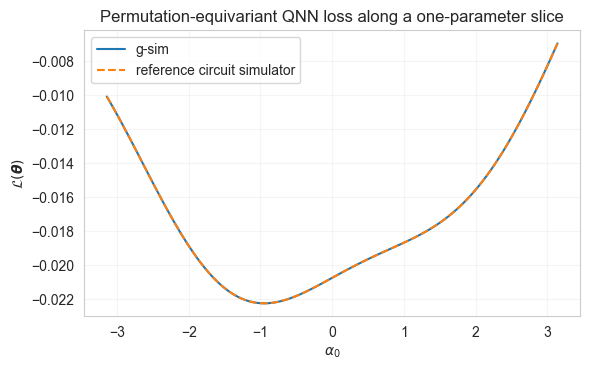

max |difference| along the slice: 8.499864320200834e-09


In [7]:
plt.figure(figsize=(6.0, 3.8))
plt.plot(scan, losses_gsim, label="g-sim", linewidth=1.5)
plt.plot(scan, losses_ref, "--", label="reference circuit simulator", linewidth=1.5)
plt.xlabel(r"$\alpha_0$")
plt.ylabel(r"$\mathcal{L}(\boldsymbol{\theta})$")
plt.title("Permutation-equivariant QNN loss along a one-parameter slice")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("max |difference| along the slice:", np.max(np.abs(losses_gsim - losses_ref)))

## 6. Remarks

- The notebook demonstrates the exact same reduced-space loss construction used in the manuscript's permutation-equivariant QNN example, but on a deliberately small instance suitable for interactive execution.
- The full large-scale experiment replaces the direct reference simulation by $\mathfrak{g}$-sim throughout and studies the variance of the loss over random parameter samples as a function of system size.
- The present implementation is intentionally problem-specific: it uses the three orbit generators $B_{1,0,0}$, $B_{0,1,0}$, and $B_{0,0,2}$ together with the normalized $XX$ readout orbit $B_{2,0,0}$. This is sufficient for a reproducible paper demonstration and can later be generalized into a more flexible experiment interface.
